# Assignment 3



- Import Libraries

In [30]:
# Loading Libraries
import re
import time
import warnings

import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy

from bs4 import BeautifulSoup, XMLParsedAsHTMLWarning
from gensim.models import FastText, Word2Vec
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, normalize
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning) # Ignore unnecessary warnings from BeautifulSoup

nltk.download('stopwords')
nltk.download('wordnet') 

nlp = spacy.load("en_core_web_sm", disable=["parser", "senter"]) # model for proper noun detection

print("--"*50)
print("Libraries loaded successfully.")
print("--"*50)

[nltk_data] Downloading package stopwords to /home/jaee/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/jaee/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


----------------------------------------------------------------------------------------------------
Libraries loaded successfully.
----------------------------------------------------------------------------------------------------


# Part A

### Load dataset

In [3]:
# Loading the dataset
data = pd.read_csv("../data/dataset_with_assignments.csv")

print("--"*50)
print("First 5 Rows of the Dataset:")
print("--"*50)
print(data.head(5))

# Dataset Information
print("--"*50)
print("Dataset Information")
print("--"*50)
print(data.info())

# Checking for missing values
print("--"*50)
print("Missing Values in Each Column:")
print("--"*50)
print(data.isnull().sum())


----------------------------------------------------------------------------------------------------
First 5 Rows of the Dataset:
----------------------------------------------------------------------------------------------------
   page_id                                                url  \
0        1                   http://0769sme.org/index-16.html   
1        4  http://aastocks.com/en/cnhk/quote/quick-quote....   
2        6  http://ada.untergrund.net/?p=boardthread&id=18...   
3        7          http://adrienedurand.wikidot.com/blog:127   
4        8  http://afrafrontpagenews.blogspot.com/2012/03/...   

                           domain  tld                  date  word_count  \
0                     0769sme.org  org  2025-12-04T20:51:02Z        2377   
1                    aastocks.com  com  2025-12-04T21:23:33Z        1738   
2              ada.untergrund.net  net  2025-12-04T20:53:54Z        3759   
3       adrienedurand.wikidot.com  com  2025-12-04T21:11:53Z        1328  

### Preprocessing
- Comparing to previous assignment with TF-IDF, we made the regex condition to be stricter, since we can't rely too much on removal by min_df and max_df as we did for TF-IDF and accidently remove semantically meaningfull words. Also, Word2Vec and FastText are more sensitive to noisy vocabularies, so we need better preprocessing for this case.
- Proper noun filtering using spaCy was considered at first, but it takes about 20min, so commented out.

In [4]:
## Use spaCy for proper noun filtering
#def build_proper_noun_set_spacy(text):
#    doc = nlp(text[:100000])  # spaCy has a character limit
#    return {token.text.lower() for token in doc
#            if token.pos_ == "PROPN"
#            and not token.is_upper  # exclude acronyms like API, CPU
#            and len(token.text) > 2}  # exclude short noise like US, UK

In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # Remove \n, \r, \t
    text = re.sub(r'[\n\r\t]+', ' ', text)
    
    # Remove URLs and emails
    text = re.sub(r'(?:https?://|ftp://|www\.)\S+|mailto:\S+|tel:\S+', '', text)
    text = re.sub(r'\b[a-z0-9._%+-]+@[a-z0-9.-]+\.[a-z]{2,}\b', '', text)

    # Remove HTML tags like <body>, but first remove script/style content
    soup = BeautifulSoup(text, 'html.parser')
    for tag in soup(['script', 'style', 'noscript']):
        tag.decompose()
    text = soup.get_text(separator=' ')

    # Build proper noun set
    # proper_nouns = build_proper_noun_set_spacy(text)

    # Split camelCases
    text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)

    # Remove proper nouns
    # text = ' '.join(w for w in text.split() if w.lower() not in proper_nouns)

    # Remove separators such as _, -, /, |, ...
    text = re.sub(r'[_\-/|]', ' ', text)
    
    # Lowercase
    text = text.lower()
        
    # Remove non-ASCII characters
    text = re.sub(r'[^\x00-\x7F]', ' ', text)

    # Normalize repeated characters like 'yessss', 'noooooo', ...
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    
    # Keep only letters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip() # remove multiple spaces

    # Tokenize and filter with stop words and lemmatization
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if len(t) >= 3
              and len(t) <= 20 # Remove very long words
              and t not in stop_words] # Keep 3 letter words like api, cpu, ...
    
    return tokens

In [6]:
# Apply preprocessing
sentences = data['full_text'].apply(preprocess).tolist()

# Find total number of tokens
total_tokens = sum(len(s) for s in sentences)

# Find average number of tokens per document
avg_tokens = np.mean([len(s) for s in sentences])

print("--"*50)
print("Preprocessing completed. Sample of cleaned text:")
print("--"*50)
print(f"Total number of tokens in the corpus: {total_tokens}")
print(f"Average number of tokens per document: {avg_tokens}")
print(f"First 5 words in First Document: {sentences[0][:5]}")  # Print first 5 tokens of the first document
print(f"First 5 words in Second Document: {sentences[1][:5]}")  # Print first 5 tokens of the second document

----------------------------------------------------------------------------------------------------
Preprocessing completed. Sample of cleaned text:
----------------------------------------------------------------------------------------------------
Total number of tokens in the corpus: 4544595
Average number of tokens per document: 719.7648083623693
First 5 words in First Document: ['best', 'resume', 'template', 'ready', 'download']
First 5 words in Second Document: ['stock', 'connect', 'quick', 'quote', 'market']


### Hyperparameter Selection

- vector_size=100
  - rule of thumb: (vocab size of each model=20,724)^(1/4) ≈ 12
  - 100 is way above minimum of 12

- window
  - CBOW: window=5 to capture semantical meaning instead of very tight windows like 2 or 3.
  - Skip-gram: window=3 since Skip-gram is more sensitive to noises.

- epochs
  - epochs=20 for CBOW since they are faster.
  - epochs=10 for Skip-gram since they were slower. 10 is still reasonable amount

- min_count=5
  - Vocab: 39,675, avg occurrences per word: 3,613,647/39,675 ≈ 91
  - The final output showed significant noisy words, especially on Skip-gram (Word2Vec Skip-gram for 'product' gives aster, bulkbuy, amplifier, rhodium, gogogate, ...)
  - We will increase min_count

- min_count=10
  - Vocab: 20,724, avg occurrences per word: 3,613,647/20,724 ≈ 174 (almost twice as bettwer)
  - The finaly output showed less noisy words
  - we will stay with min_count=10

In [7]:
param_cbow = dict(
    vector_size=100,   # embedding dimensions (no need to go high for 6,000 docs)
    window=5,          # context window size (for clustering and topic analysis, avoid too small windows)
    min_count=10,      # ignore words with freq < 10 (remove noisy vocabs)
    sg=0,              # 0 = CBOW, 1 = Skip-gram
    workers=4,         # parallel threads
    epochs=20          # training iterations (CBOW is faster, so set it higher)
    )

param_skipgram = dict(
    vector_size=100,       # embedding dimensions (no need to go high for 6,000 docs)
    window=3,              # context window size (for clustering and topic analysis, avoid too small windows)
    min_count=10,          # ignore words with freq < 10 (remove noisy vocabs)
    sg=1,                  # 0 = CBOW, 1 = Skip-gram
    workers=4,             # parallel threads
    epochs=10,             # training iterations (Skip-gram is slower, so set it lower)
)

### Word2Vec Training - CBOW

In [8]:
start_time = time.time()

model_cbow = Word2Vec(sentences=sentences, **param_cbow)

time_cbow = round(time.time() - start_time, 4)
print(f"Elapsed time for Word2Vec CBOW: {time_cbow:.4f} seconds")

Elapsed time for Word2Vec CBOW: 22.3580 seconds


### Word2Vec Training - Skip-gram

In [9]:
start_time = time.time()

model_skipgram = Word2Vec(sentences=sentences, **param_skipgram)

time_skipgram = round(time.time() - start_time, 4)
print(f"Elapsed time for Word2Vec Skip-gram: {time_skipgram:.4f} seconds")

Elapsed time for Word2Vec Skip-gram: 29.6708 seconds


### FastText Training - CBOW

In [10]:
start_time = time.time()

model_fasttext_cbow = FastText(sentences=sentences, 
                               **param_cbow,
                               min_n=3, # min char n-gram size
                               max_n=6, # max char n-gram size
                               )

time_ft_cbow = round(time.time() - start_time, 4)
print(f"Elapsed time for FastText CBOW: {time_ft_cbow:.4f} seconds")

Elapsed time for FastText CBOW: 109.7477 seconds


### FastText Training - Skip-gram

In [11]:
start_time = time.time()

model_fasttext_skipgram = FastText(sentences=sentences, 
                                   **param_skipgram,
                                    min_n=3, # min char n-gram size
                                    max_n=6, # max char n-gram size
                                   )

time_ft_skipgram = round(time.time() - start_time, 4)
print(f"Elapsed time for FastText Skip-gram: {time_ft_skipgram:.4f} seconds")

Elapsed time for FastText Skip-gram: 61.2838 seconds


### Embedding Exploration

In [12]:
# Print vocabulary size and embedding dimensions
training_summary = pd.DataFrame({
    'Model':       ['Word2Vec CBOW', 'Word2Vec Skip-gram', 'FastText CBOW', 'FastText Skip-gram'],
    'Time (s)':    [time_cbow, time_skipgram, time_ft_cbow, time_ft_skipgram],
    'Vocab Size':  [len(m.wv) for m in [model_cbow, model_skipgram, model_fasttext_cbow, model_fasttext_skipgram]],
    'Vector Size': [m.vector_size for m in [model_cbow, model_skipgram, model_fasttext_cbow, model_fasttext_skipgram]],
})

print(training_summary)

                Model  Time (s)  Vocab Size  Vector Size
0       Word2Vec CBOW   22.3580       27410          100
1  Word2Vec Skip-gram   29.6708       27410          100
2       FastText CBOW  109.7477       27410          100
3  FastText Skip-gram   61.2838       27410          100


In [13]:
# Find top=n similar words for given query words in a model
def find_similar_words(model, query_words, topn=10):
    results = []
    for word in query_words:
        if word in model.wv:
            similar = model.wv.most_similar(word, topn=topn)
            for rank, (similar_word, score) in enumerate(similar, 1):
                results.append({
                    'query': word,
                    'rank':  rank,
                    'similar_word': similar_word,
                    'score': round(score, 4)
                })
        else:
            print(f"Warning: '{word}' not in vocabulary")
    return pd.DataFrame(results)

model_order = ['Word2Vec CBOW', 'Word2Vec Skip-gram', 'FastText CBOW', 'FastText Skip-gram']

# Pivot: rows = rank, columns = each model's (similar_word, score)
def compare_query_word(df_all, query_word):
    subset = df_all[df_all['query'] == query_word].copy()
    
    # Build a multi-column df per model
    frames = {}
    for model_name in model_order:
        m = subset[subset['model'] == model_name][['rank', 'similar_word', 'score']]
        m = m.set_index('rank')
        m.columns = [model_name, 'score']
        frames[model_name] = m
    
    combined = pd.concat(frames.values(), axis=1)
    return combined

In [14]:
# Define query words for each categories
categories = {
    'ECOMMERCE':  ['price', 'product', 'shipping'],
    'GOVERNMENT': ['legislation', 'regulation', 'official'],
    'TECHNICAL':  ['software', 'hardware', 'development'],
    'NEWS':       ['report', 'news', 'coverage'],
    'BLOG':       ['comment', 'blog', 'post'],
    'EDUCATIONAL':['student', 'curriculum', 'academic'],
    'OTHER' :     ['contact', 'event', 'forum'] # OTHER category is expected to be noisy since it is any generic document that doesn't fit the above.
}
query_words = [word for words in categories.values() for word in words]

# Collect results from all models
models_dict = {
    'Word2Vec CBOW': model_cbow,
    'Word2Vec Skip-gram': model_skipgram,
    'FastText CBOW': model_fasttext_cbow,
    'FastText Skip-gram': model_fasttext_skipgram
}

all_dfs = []
for model_name, model in models_dict.items():
    df = find_similar_words(model, query_words, topn=10)
    df['model'] = model_name
    all_dfs.append(df)

df_all = pd.concat(all_dfs, ignore_index=True)

for category, words in categories.items():
    print(f"\n{'='*80}")
    print(f"  CATEGORY: {category}")
    print(f"{'='*80}")
    for word in words:
        if word in df_all['query'].values:
            print("-" * 80)
            print(f"  Query: '{word}'")
            print("-" * 80)
            result = compare_query_word(df_all, word)
            print(result.to_string())



  CATEGORY: ECOMMERCE
--------------------------------------------------------------------------------
  Query: 'price'
--------------------------------------------------------------------------------
     Word2Vec CBOW   score Word2Vec Skip-gram   score       FastText CBOW   score FastText Skip-gram   score
rank                                                                                                        
1             msrp  0.5812                rrp  0.7112             ecprice  0.9012             priced  0.7371
2              qty  0.5447           pidilite  0.6688              priced  0.8198            ecprice  0.7018
3         quantity  0.5405     alphabetically  0.6313             pricing  0.5739                rrp  0.6679
4           priced  0.5307                qty  0.6099                 qty  0.5713           pidilite  0.6557
5         discount  0.5290         advertised  0.6034            discount  0.5504           autosell  0.5915
6            stock  0.5219         

# Part B

### Simple Mean Averaging
- Simple mean averaging adds up all the vectors in a document, and average them, so it represents the frequency of the words appearing in the document.

In [15]:
def doc_vector_avg(tokens, model):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if not vecs:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

doc_vecs_cbow      = np.array([doc_vector_avg(s, model_cbow)             for s in sentences])
doc_vecs_skipgram  = np.array([doc_vector_avg(s, model_skipgram)         for s in sentences])
doc_vecs_ft_cbow   = np.array([doc_vector_avg(s, model_fasttext_cbow)    for s in sentences])
doc_vecs_ft_sg     = np.array([doc_vector_avg(s, model_fasttext_skipgram) for s in sentences])

### TF-IDF Averaging
- Unlike simple mean averaging, TF-IDF averaging adds up vectors of a document with a proper weighting by TF-IDF scores, thus represents semantically meaningful words (which has higher TF-IDF scores) more by applying higher weights on them.

In [16]:
corpus_str = [' '.join(s) for s in sentences]

tfidf = TfidfVectorizer()
tfidf.fit(corpus_str)
vocab = tfidf.vocabulary_
idf   = tfidf.idf_

def doc_vector_tfidf(tokens, model):
    vecs, weights = [], []
    for t in tokens:
        if t in model.wv and t in vocab:
            vecs.append(model.wv[t])
            weights.append(idf[vocab[t]])
    if not vecs:
        return np.zeros(model.vector_size)
    weights = np.array(weights)
    return np.average(vecs, axis=0, weights=weights)

doc_vecs_cbow_tfidf = np.array([doc_vector_tfidf(s, model_cbow) for s in sentences])
doc_vecs_skipgram_tfidf = np.array([doc_vector_tfidf(s, model_skipgram) for s in sentences])
doc_vecs_ft_cbow_tfidf = np.array([doc_vector_tfidf(s, model_fasttext_cbow) for s in sentences])
doc_vecs_ft_sg_tfidf = np.array([doc_vector_tfidf(s, model_fasttext_skipgram) for s in sentences])

## Classification
- Using smaller dataset with manual labels.

In [18]:
# Loading the dataset
data_label = pd.read_csv("../data/english_pages_metadata_clean_with_labels.csv")
data_label['full_text_clean'] = data_label['full_text'].apply(lambda x: ' '.join(preprocess(x)))

print("--"*50)
print("First 5 Rows of the Dataset:")
print("--"*50)
print(data_label.head(5))

# Dataset Information
print("--"*50)
print("Dataset Information")
print("--"*50)
print(data_label.info())

# Checking for missing values
print("--"*50)
print("Missing Values in Each Column:")
print("--"*50)
print(data_label.isnull().sum())


----------------------------------------------------------------------------------------------------
First 5 Rows of the Dataset:
----------------------------------------------------------------------------------------------------
   page_id                            assigned_to manual_label  \
0    655.0  Vinay Varshigan Sivakumar Jayalakshmi    ecommerce   
1    656.0  Vinay Varshigan Sivakumar Jayalakshmi         blog   
2    657.0  Vinay Varshigan Sivakumar Jayalakshmi         news   
3    658.0  Vinay Varshigan Sivakumar Jayalakshmi         blog   
4    661.0  Vinay Varshigan Sivakumar Jayalakshmi        other   

  manual_label_clean manual_label_final  \
0          ECOMMERCE          ECOMMERCE   
1               BLOG               BLOG   
2               NEWS               NEWS   
3               BLOG               BLOG   
4              OTHER              OTHER   

                                           full_text _merge  \
0  Fall arrest and work positioning harness – All.

## Train and Compare Random Forest and XGBoost

In [37]:
# Load dataset and encode labels
X = data_label['full_text_clean']
y = data_label['manual_label_final']

le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# Train models
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")
rf.fit(X_train_tfidf, y_train)

print("Training XGBoost...")
xgb.fit(X_train_tfidf, y_train,
        eval_set=[(X_test_tfidf, y_test)],
        verbose=False)

# Evaluation
str_labels = list(le.classes_)  # original string labels, sorted

def evaluate(name, model, X_test, y_test):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    # Decode to string labels for readable reports
    y_test_str = le.inverse_transform(y_test)
    y_pred_str = le.inverse_transform(y_pred)

    acc = accuracy_score(y_test_str, y_pred_str)
    auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"\n{classification_report(y_test_str, y_pred_str, labels=str_labels)}")

    return {"model": name, "accuracy": acc, "roc_auc": auc,
            "y_pred_str": y_pred_str, "y_proba": y_proba}

rf_results  = evaluate("Random Forest", rf,  X_test_tfidf, y_test)
xgb_results = evaluate("XGBoost",       xgb, X_test_tfidf, y_test)

# Comparison
summary = pd.DataFrame([
    {k: v for k, v in rf_results.items()  if k not in ("y_pred_str", "y_proba")},
    {k: v for k, v in xgb_results.items() if k not in ("y_pred_str", "y_proba")},
])
print("\n============= Summary =================")
print(summary.to_string(index=False))
best = summary.loc[summary["roc_auc"].idxmax(), "model"]
print(f"\n✅ Best model by ROC-AUC: {best}")


Label mapping: {'BLOG': np.int64(0), 'ECOMMERCE': np.int64(1), 'EDUCATION': np.int64(2), 'FORUM/DISCUSSION': np.int64(3), 'GOVERNMENT': np.int64(4), 'NEWS': np.int64(5), 'OTHER': np.int64(6), 'TECHNICAL': np.int64(7)}
Training Random Forest...
Training XGBoost...

  Random Forest
  Accuracy : 0.5083
  ROC-AUC  : 0.8386

                  precision    recall  f1-score   support

            BLOG       0.68      0.68      0.68        25
       ECOMMERCE       0.67      0.61      0.64        23
       EDUCATION       0.75      0.25      0.38        12
FORUM/DISCUSSION       1.00      0.56      0.71         9
      GOVERNMENT       0.00      0.00      0.00         3
            NEWS       0.00      0.00      0.00         9
           OTHER       0.35      0.69      0.47        32
       TECHNICAL       0.00      0.00      0.00         7

        accuracy                           0.51       120
       macro avg       0.43      0.35      0.36       120
    weighted avg       0.51      0.51 

/home/jaee/miniconda3/envs/jupyter/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jaee/miniconda3/envs/jupyter/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jaee/miniconda3/envs/jupyter/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

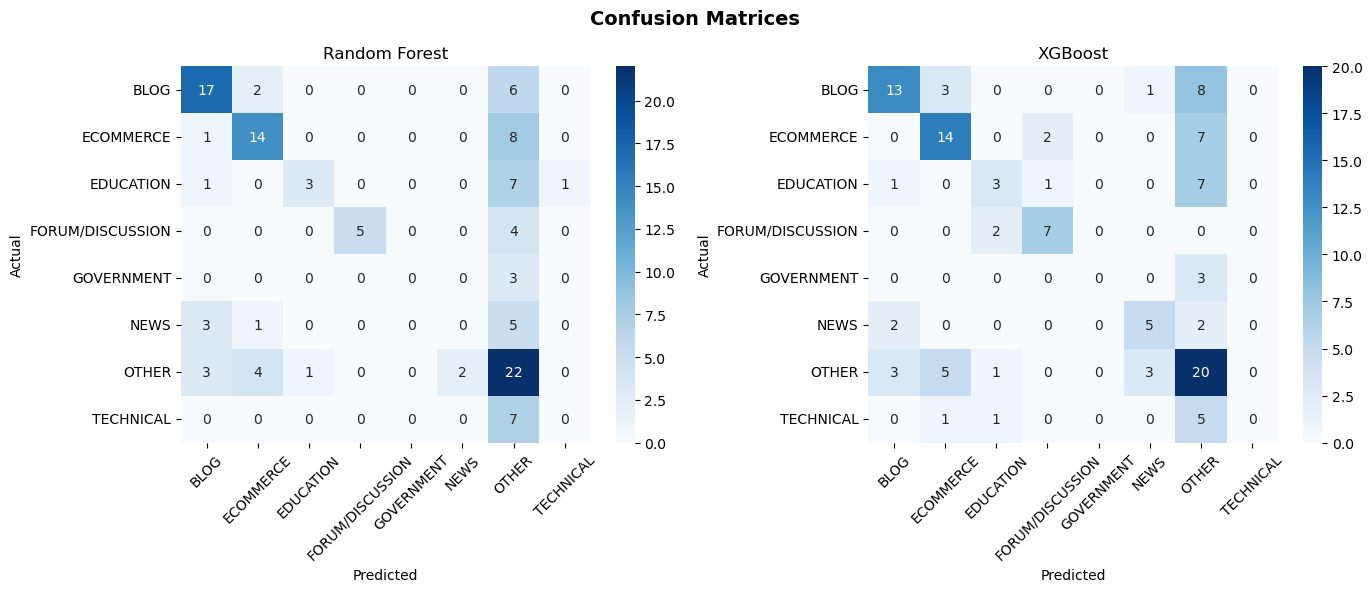

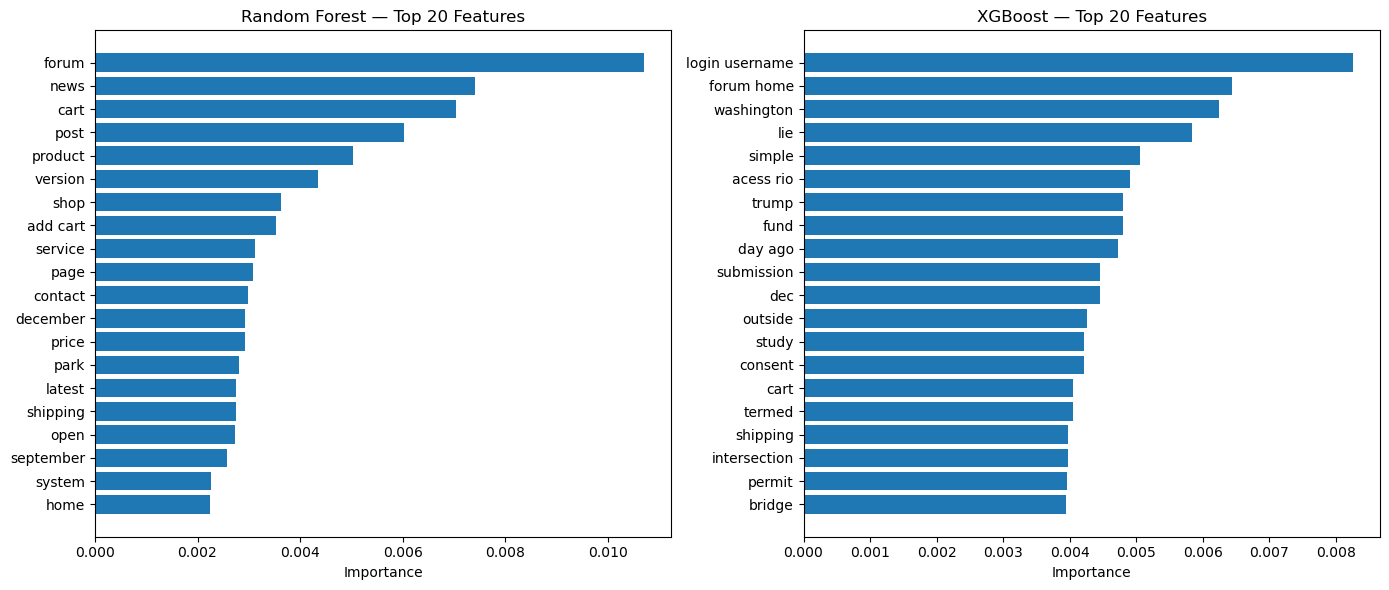

In [38]:
# Confusion Matrices
y_test_str = le.inverse_transform(y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, res in zip(axes, [rf_results, xgb_results]):
    cm = confusion_matrix(y_test_str, res["y_pred_str"], labels=str_labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=str_labels, yticklabels=str_labels, ax=ax)
    ax.set_title(res["model"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

# Top 20 features
TOP_N = 20
feature_names = tfidf.get_feature_names_out()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, model, name in [(axes[0], rf, "Random Forest"), (axes[1], xgb, "XGBoost")]:
    top_idx = np.argsort(model.feature_importances_)[-TOP_N:]
    ax.barh(feature_names[top_idx], model.feature_importances_[top_idx])
    ax.set_title(f"{name} — Top {TOP_N} Features")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.savefig("feature_importances.png", dpi=150)
plt.show()

## Evaluation and Comparison

In [41]:
# load and encode labels
y = data_label["manual_label_final"]
le = LabelEncoder()
y_enc = le.fit_transform(y)
str_labels = list(le.classes_)

labeled_indices = data_label["page_id"].map(
    dict(zip(data["page_id"], range(len(data))))
).values

# Normalized embeddings
embeddings = {
    "Word2Vec CBOW  + Mean":   normalize(doc_vecs_cbow[labeled_indices]),
    "Word2Vec CBOW  + TF-IDF": normalize(doc_vecs_cbow_tfidf[labeled_indices]),
    "Word2Vec SG    + Mean":   normalize(doc_vecs_skipgram[labeled_indices]),
    "Word2Vec SG    + TF-IDF": normalize(doc_vecs_skipgram_tfidf[labeled_indices]),
    "FastText CBOW  + Mean":   normalize(doc_vecs_ft_cbow[labeled_indices]),
    "FastText CBOW  + TF-IDF": normalize(doc_vecs_ft_cbow_tfidf[labeled_indices]),
    "FastText SG    + Mean":   normalize(doc_vecs_ft_sg[labeled_indices]),
    "FastText SG    + TF-IDF": normalize(doc_vecs_ft_sg_tfidf[labeled_indices]),
}

# train test split
split_idx = np.arange(len(y_enc))
train_idx, test_idx = train_test_split(
    split_idx,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)
y_train, y_test = y_enc[train_idx], y_enc[test_idx]

# evaluation with XGBoost
def evaluate_embedding(name, X_train, X_test, y_train, y_test):
    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )
    xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    y_pred  = xgb.predict(X_test)
    y_proba = xgb.predict_proba(X_test)

    y_test_str = le.inverse_transform(y_test)
    y_pred_str = le.inverse_transform(y_pred)

    acc = accuracy_score(y_test_str, y_pred_str)
    auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")

    report = classification_report(y_test_str, y_pred_str,
                                   labels=str_labels, zero_division=0,
                                   output_dict=True)
    precision = report["macro avg"]["precision"]
    recall    = report["macro avg"]["recall"]
    f1        = report["macro avg"]["f1-score"]

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Accuracy : {acc:.4f}  |  ROC-AUC  : {auc:.4f}")
    print(f"  Precision: {precision:.4f}  |  Recall   : {recall:.4f}  |  F1: {f1:.4f}")
    print(classification_report(y_test_str, y_pred_str,
                                labels=str_labels, zero_division=0))
    return {
        "Embedding": name,
        "Accuracy":  acc,
        "Precision": precision,
        "Recall":    recall,
        "F1":        f1,
        "ROC-AUC":   auc,
    }

# Comparisons
results = []
for name, X in embeddings.items():
    X_train, X_test = X[train_idx], X[test_idx]
    results.append(evaluate_embedding(name, X_train, X_test, y_train, y_test))

# Summary
summary = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

summary[["Model", "Variant", "Averaging"]] = summary["Embedding"].str.extract(
    r"(Word2Vec|FastText)\s+(CBOW|SG)\s+\+\s+(Mean|TF-IDF)"
)
summary = summary[["Model", "Variant", "Averaging", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]
summary.insert(0, "Rank", range(1, len(summary) + 1))
for col in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    summary[col] = summary[col].map("{:.4f}".format)

pivot_df = pd.DataFrame(results)
pivot_df[["Model", "Variant", "Averaging"]] = pivot_df["Embedding"].str.extract(
    r"(Word2Vec|FastText)\s+(CBOW|SG)\s+\+\s+(Mean|TF-IDF)"
)

def make_pivot(metric):
    return pivot_df.pivot_table(
        index=["Model", "Variant"], columns="Averaging", values=metric
    ).round(4)

print("\n" + "="*75)
print("  RANKED RESULTS (sorted by ROC-AUC, macro avg)")
print("="*75)
print(summary.to_string(index=False))

for metric in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    print(f"\n{'='*55}")
    print(f"  {metric.upper()}  —  Mean vs TF-IDF Averaging")
    print("="*55)
    print(make_pivot(metric).to_string())

best = summary.iloc[0]
print(f"\n✅ Best: {best['Model']} {best['Variant']} + {best['Averaging']}"
      f"  (Acc={best['Accuracy']}, P={best['Precision']},"
      f" R={best['Recall']}, F1={best['F1']}, AUC={best['ROC-AUC']})")


  Word2Vec CBOW  + Mean
  Accuracy : 0.5333  |  ROC-AUC  : 0.8343
  Precision: 0.4656  |  Recall   : 0.4422  |  F1: 0.4464
                  precision    recall  f1-score   support

            BLOG       0.60      0.60      0.60        25
       ECOMMERCE       0.61      0.74      0.67        23
       EDUCATION       0.57      0.33      0.42        12
FORUM/DISCUSSION       0.88      0.78      0.82         9
      GOVERNMENT       0.00      0.00      0.00         3
            NEWS       0.40      0.44      0.42         9
           OTHER       0.42      0.50      0.46        32
       TECHNICAL       0.25      0.14      0.18         7

        accuracy                           0.53       120
       macro avg       0.47      0.44      0.45       120
    weighted avg       0.52      0.53      0.52       120


  Word2Vec CBOW  + TF-IDF
  Accuracy : 0.5167  |  ROC-AUC  : 0.7979
  Precision: 0.4722  |  Recall   : 0.4092  |  F1: 0.4225
                  precision    recall  f1-score   s

- Word2Vec CBOW + Mean averaging showed the best result.

## Prediction

In [42]:
# Encode labels
y = data_label["manual_label_final"]
le = LabelEncoder()
y_enc = le.fit_transform(y)

# prepare embeddings
labeled_indices = data_label["page_id"].map(
    dict(zip(data["page_id"], range(len(data))))
).values

X_labeled = normalize(doc_vecs_cbow[labeled_indices])

# train all labelled data with XGBoost
xgb_final = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)
xgb_final.fit(X_labeled, y_enc)
print("✅ Model trained on all labeled data.")

# find unlabelled indices
all_indices      = set(range(len(data)))
labeled_idx_set  = set(labeled_indices.tolist())
unlabeled_indices = np.array(sorted(all_indices - labeled_idx_set))

print(f"   Labeled   : {len(labeled_indices):,}")
print(f"   Unlabeled : {len(unlabeled_indices):,}")
print(f"   Total     : {len(data):,}")

# Prediction on unlabelled data
X_unlabeled = normalize(doc_vecs_cbow[unlabeled_indices])

y_pred_enc  = xgb_final.predict(X_unlabeled)
y_pred_str  = le.inverse_transform(y_pred_enc)
y_pred_prob = xgb_final.predict_proba(X_unlabeled)

# result
unlabeled_data = data.iloc[unlabeled_indices].copy().reset_index(drop=True)

result = unlabeled_data[["page_id", "url"]].copy()
result["predicted_label"]      = y_pred_str
result["confidence"]           = y_pred_prob.max(axis=1).round(4)

# Probability distribution
prob_cols = pd.DataFrame(y_pred_prob, columns=[f"prob_{c}" for c in le.classes_])
result = pd.concat([result, prob_cols.round(4)], axis=1)

print(f"\n── Prediction distribution ──────────────────────────────")
print(result["predicted_label"].value_counts().to_string())

print(f"\n── Sample predictions (first 10) ────────────────────────")
print(result[["page_id", "url", "predicted_label", "confidence"]].head(10).to_string(index=False))

# save to csv
result.to_csv("../data/unlabeled_predictions.csv", index=False)
print("\n✅ Saved to unlabeled_predictions.csv")

✅ Model trained on all labeled data.
   Labeled   : 596
   Unlabeled : 5,718
   Total     : 6,314

── Prediction distribution ──────────────────────────────
predicted_label
OTHER               2002
ECOMMERCE           1458
BLOG                 982
EDUCATION            469
NEWS                 394
FORUM/DISCUSSION     211
TECHNICAL            188
GOVERNMENT            14

── Sample predictions (first 10) ────────────────────────
 page_id                                                                                                                                                                                                             url  predicted_label  confidence
     117                                                                                                                                       http://gratisideen.de/phpBB2/faq.php?sid=366e356aed7b81192dcc53b1217d42c7 FORUM/DISCUSSION      0.9865
     119                                                                    